In [154]:
from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Dict, Iterable, List, Optional, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [155]:
class Problem(ABC):
    """Abstract base class for a search problem."""

    @abstractmethod
    def initial_state(self) -> Any:
        """Return the start state."""
        pass

    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        """Return True if state is a goal state."""
        pass

    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        """Return the legal actions available in the given state."""
        pass

    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        """Return the next state after applying action in state."""
        pass

    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        """Return the cost of applying action in state to reach next_state."""
        pass


In [173]:
@dataclass
class Node:
    state: Any
    parent: Optional["Node"] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = (
                self.parent.depth + 1
            )  # increases the depth of the childs depth by the parents +1 if it has a parent


@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    @property
    def path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return reconstruct_path(self.solution)

    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth

    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
            return None
        return self.solution.path_cost


In [174]:
def reconstruct_path(node: Node) -> List[Any]:
    """Return the list of states from the root node to this node."""
    path = []

    while node is not None:
        path.append(node.state)
        node = node.parent

    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    """Return the list of actions from the root node to this node."""
    actions = []

    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent

    actions.reverse()
    return actions


def state_is_on_path(node: Node, state: Any) -> bool:
    """
    Return True if state already appears on the path from the root to node.

    This is useful for depth-limited search because DLS often uses path-cycle
    checking instead of a global reached set.
    """
    while node is not None:
        if node.state == state:
            return True
        node = node.parent

    return False


def result_to_row(result: SearchResult) -> Dict[str, Any]:
    """Convert a SearchResult object into a row for a pandas DataFrame."""
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Limit": result.limit,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier/stack": result.max_frontier_size,
        "Reached states": result.reached_count,
    }


def show_results(results: List[SearchResult]) -> pd.DataFrame:
    """Display results as a DataFrame."""
    return pd.DataFrame([result_to_row(r) for r in results])


In [187]:
MOVES = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1),
}


class GridProblem(Problem):
    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        start, goal:
            Tuples in the form (row, col).
        """
        self.grid = grid
        self.start = start
        self.goal = goal

        self.rows = len(grid)
        self.cols = len(grid[0])

    def initial_state(self) -> Tuple[int, int]:
        return self.start

    def is_goal(self, state: Tuple[int, int]) -> bool:
        # TODO 1:
        return state == self.goal

    def in_bounds(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    def is_free(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return self.grid[row][col] == 0

    def actions(self, state: Tuple[int, int]) -> List[str]:
        # TODO 2:
        # Return a list of legal action names.
        #
        # Steps:
        # 1. Create an empty list called legal_actions.
        legal_actions = []
        # 2. For each action in MOVES:
        #       a. Compute the neighbour cell.
        #       b. Check that it is in bounds.
        #       c. Check that it is free.
        #       d. If valid, add the action name to legal_actions.
        # 3. Return legal_actions.
        for key in MOVES:
            values=MOVES[key]
            n_cell = (state[0]+values[0],state[1]+values[1])
            row,col=state[0]+values[0],state[1]+values[1]
            if (n_cell[0] > -1 and n_cell[1] >-1) and (n_cell[0]<len(self.grid) and n_cell[1]<len(self.grid[0]) ):# makes sure its not a negative number or outside bounds
                if self.grid[row][col] == 0:
                    legal_actions.append(key)
        
        return legal_actions

    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
        # TODO 3:
        # Return the next state after applying action to state.
        #
        row, col = state  # assigns current coordinates to the row and col variables
        dr, dc = MOVES[action]  # assigns action movement to the variables
        return (row + dr, col + dc)  # returns new row and colums

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        # TODO 4:
        # In this lab, each valid move has a cost of 1.
        return 1.0


In [188]:
test_grid = [
    [0, 0, 0],
    [1, 1, 0],
    [0, 0, 0],
]

test_problem = GridProblem(test_grid, start=(0, 0), goal=(2, 2))
# print(test_problem.initial_state())
# print(test_problem.actions((0, 0)))
assert test_problem.initial_state() == (0, 0)
assert test_problem.is_goal((2, 2)) is True
assert test_problem.is_goal((0, 0)) is False
assert test_problem.actions((0, 0)) == ["RIGHT"]
assert test_problem.result((0, 0), "RIGHT") == (0, 1)
assert test_problem.action_cost((0, 0), "RIGHT", (0, 1)) == 1

print("GridProblem self-check passed.")

GridProblem self-check passed.


In [177]:
sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

problem = GridProblem(sample_grid, start, goal)

In [179]:
def plot_path(
    grid: List[List[int]],
    start: Optional[Tuple[int, int]] = None,
    goal: Optional[Tuple[int, int]] = None,
    path: Optional[List[Tuple[int, int]]] = None,
    terrain_costs: Optional[List[List[float]]] = None,
    title: str = "Grid Map",
):
    """Visualise a grid and, optionally, a solution path."""
    arr = np.array(grid)
    height, width = arr.shape

    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)

            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)
            else:
                fill = (0.95, 0.95, 0.95)

            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)

            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5,
                    row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    plt.show()

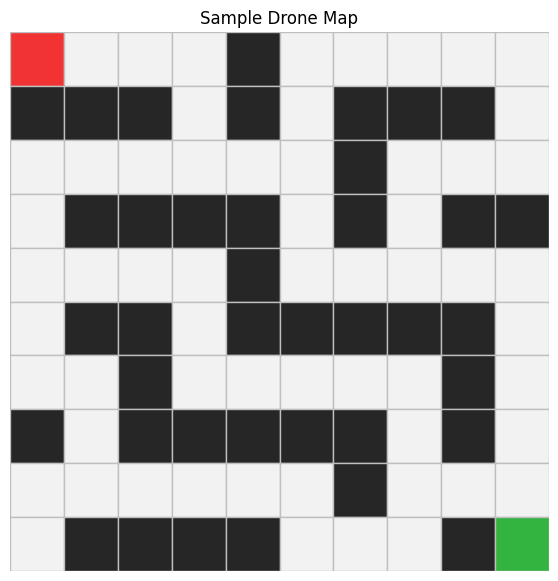

In [162]:
plot_path(sample_grid, start, goal, title="Sample Drone Map")

In [180]:
class SearchAlgorithm(ABC):
    """Base class for search algorithms."""

    def expand(self, problem: Problem, node: Node) -> Iterable[Node]:
        # TODO 5:
        # Implement the AIMA-style EXPAND(problem, node).
        #
        # Pseudocode:
        # s <- node.STATE
        # for each action in problem.ACTIONS(s):
        #     s_prime <- problem.RESULT(s, action)
        #     cost <- node.PATH_COST + problem.ACTION_COST(s, action, s_prime)
        #     yield NODE(STATE=s_prime, PARENT=node, ACTION=action, PATH_COST=cost)
        s= node.state
        nodes=[]
        for action in problem.actions(s):
            s_prime=problem.result(s,action)
            cost=node.path_cost + problem.action_cost(s, action, s_prime)
            nodes.append(Node(state=s_prime, parent=node, action=action, path_cost=cost))
        return nodes

    @abstractmethod
    def search(self, problem: Problem) -> SearchResult:
        pass

In [181]:
class BreadthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "BFS"

        # TODO 6:
        # Implement BFS graph search using a FIFO queue.
        #
        # Steps:
        # 1. Create the initial node from problem.initial_state().
        # 2. If the initial state is the goal, return success.
        # 3. Create a deque frontier and add the initial node.
        # 4. Create a reached set and add the initial state.
        # 5. While frontier is not empty:
        #       a. pop from the LEFT of the deque.
        #       b. increment nodes_expanded.
        #       c. expand the node.
        #       d. for each child:
        #            i. if child is goal, return success.
        #           ii. if child.state is not in reached:
        #                  add child.state to reached.
        #                  append child to frontier.
        #       e. update max_frontier_size.
        # 6. Return failure if no solution is found.
        node=Node(state=problem.initial_state())
        nodes_expanded=0
        if problem.is_goal(node.state):
            return node
        
        frontier = deque([node])
        children=deque()
        reached={problem.initial_state()}
        max_frontier_size=1
        while frontier:
            node=frontier.popleft()
            nodes_expanded+=1
            for child in self.expand(problem,node):
                s=child.state
                if problem.is_goal(s):
                    return SearchResult(algorithm=algorithm,status='success', solution=child ,nodes_expanded=nodes_expanded, max_frontier_size=max_frontier_size)
                
                if s not in reached:
                    reached.add(s)
                    frontier.append(child)
            max_frontier_size+=1
        
        return SearchResult(algorithm=algorithm,status='faliure',nodes_expanded=nodes_expanded, max_frontier_size=max_frontier_size, solution=None)
        # Hint:
        # frontier = deque([node])
        # node = frontier.popleft()
    


In [165]:
class DepthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "DFS"

        # TODO 7:
        # Implement DFS graph search using a stack.
        #
        # Steps:
        # 1. Create the initial node.
        # 2. If the initial state is the goal, return success.
        # 3. Use a Python list as the stack frontier.
        # 4. Use a reached set.
        # 5. While frontier is not empty:
        #       a. pop from the end of the list.
        #       b. increment nodes_expanded.
        #       c. expand the node.
        #       d. add unreached children to the stack.
        #       e. update max_frontier_size.
        #
        # Note:
        # If you want DFS to explore actions in the same order as MOVES,
        # you may need to reverse the children before pushing them.
        node=Node(state=problem.initial_state())
        if problem.is_goal(node.state):
            return node
        
        frontier = deque([node])
        reached={problem.initial_state()}
        nodes_expanded=1
        max_frontier_size=1
        while frontier:
            node=frontier.pop()
            nodes_expanded+=1
            max_frontier_size+=1
            for child in self.expand(problem,node):
                s=child.state
                if problem.is_goal(s):
                    return SearchResult(algorithm=algorithm,status='success',solution=child,nodes_expanded=nodes_expanded, max_frontier_size=max_frontier_size)
                
                if s not in reached:
                    reached.add(s)
                    frontier.append(child)
                
        
        return SearchResult(algorithm=algorithm,status='failure',nodes_expanded=nodes_expanded, max_frontier_size=max_frontier_size, solution=None)

In [166]:
class DepthLimitedSearch(SearchAlgorithm):
    def search(self, problem: Problem, limit: int = 10) -> SearchResult:
        algorithm = "DLS"

        initial_node = Node(problem.initial_state())

        metrics = {
            "nodes_expanded": 0,
            "max_stack_size": 1,
        }

        solution, status = self._recursive_dls(
            problem=problem,
            node=initial_node,
            limit=limit,
            metrics=metrics,
            current_stack_size=1,
        )

        return SearchResult(
            algorithm=algorithm,
            status=status,
            solution=solution,
            nodes_expanded=metrics["nodes_expanded"],
            max_frontier_size=metrics["max_stack_size"],
            reached_count=0,
            limit=limit,
        )

    
    def _recursive_dls(
        self,
        problem: Problem,
        node: Node,
        limit: int,
        metrics: Dict[str, int],
        current_stack_size: int,
    ) -> Tuple[Optional[Node], str]:
        # TODO 8:
        # Implement recursive depth-limited search.
        #
        # Steps:
        # 1. If node.state is goal, return (node, "success").
        if problem.is_goal(node.state):
            return (node,"success")
        # 2. Else if node.depth >= limit, return (None, "cutoff").
        elif node.depth >= limit:
            cutoff_occurred=True
            return (None, "cutoff")
        # 3. Otherwise:
        #       a. increment metrics["nodes_expanded"].
        #       b. set cutoff_occurred = False.
        #       c. for each child in expand(problem, node):
        #             i. skip the child if child.state already appears on the current path.
        #            ii. update max_stack_size.
        #           iii. recursively call _recursive_dls on the child.
        #            iv. if result is "success", return success immediately.
        #             v. if result is "cutoff", set cutoff_occurred = True.
        #       d. after all children:
        #             if cutoff_occurred, return (None, "cutoff")
        #             else return (None, "failure")
        else:
            metrics["nodes_expanded"]+=1
            cutoff_occurred = False
            for child in self.expand(problem,node):
                if child.state != node.parent and child.state!= node.state:
                    continue
                result, status= self._recursive_dls(problem,child,limit)
                if result=='success':
                    return (child,'success')
                if result=='cut_off':
                    cutoff_occurred=True
            if cutoff_occurred:
                return (None, "cutoff")
            else:
                return (None, "failure")


    def depth_limited_search(self,problem: Problem, limit:int) -> Tuple[Optional[Node], str]:
        node = Node(problem.initial_state())
        return self._recursive_dls(node, problem, limit)

In [167]:
class IterativeDeepeningSearch(SearchAlgorithm):
    def search(self, problem: Problem, max_depth: int = 50) -> SearchResult:
        algorithm = "IDS"

        # TODO 9:
        # Implement IDS by repeatedly running DLS from limit 0 to max_depth.
        #
        # Requirements:
        # 1. Keep a list called iteration_log.
        # 2. Accumulate total nodes expanded across all DLS iterations.
        # 3. Track the maximum stack size seen in any DLS run.
        # 4. If a DLS run returns success, return a SearchResult for IDS.
        # 5. If a DLS run returns failure, IDS can stop early and return failure.
        # 6. If all limits return cutoff up to max_depth, return cutoff.
        max_frontier_size=1
        iteration_log=[]
        limit=0
        nodes_expanded=0
        for limit in range(max_depth):
            max_frontier_size+=1
            nodes_expanded+=1
            dls = DepthLimitedSearch()
            result= dls.search(problem, limit=limit)
            iteration_log.append((result.limit,result.status))
            if result.status== "success":
                return SearchResult(algorithm=algorithm,status=result.status,limit=limit, max_frontier_size=max_frontier_size)
            elif result.status=="faliure":
                return SearchResult(algorithm=algorithm,status=result.status,limit=limit, max_frontier_size=max_frontier_size)
        return SearchResult(algorithm=algorithm,solution=None,status="cutoff",limit=limit, max_frontier_size=max_frontier_size,nodes_expanded=nodes_expanded)
        

        # Hint:
        # dls = DepthLimitedSearch()
        # result = dls.search(problem, limit=limit)

In [168]:
bfs = BreadthFirstSearch()
dfs = DepthFirstSearch()
dls = DepthLimitedSearch()
ids = IterativeDeepeningSearch()

results = [
    bfs.search(problem),
    dfs.search(problem),
    dls.search(problem, limit=10),
    ids.search(problem, max_depth=30),
]
show_results(results)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,18.0,18.0,50,50,0
1,DFS,success,NaN,18.0,18.0,19,19,0
2,DLS,failure,10.0,NaN,NaN,1,1,0
3,IDS,cutoff,29.0,NaN,NaN,30,31,0


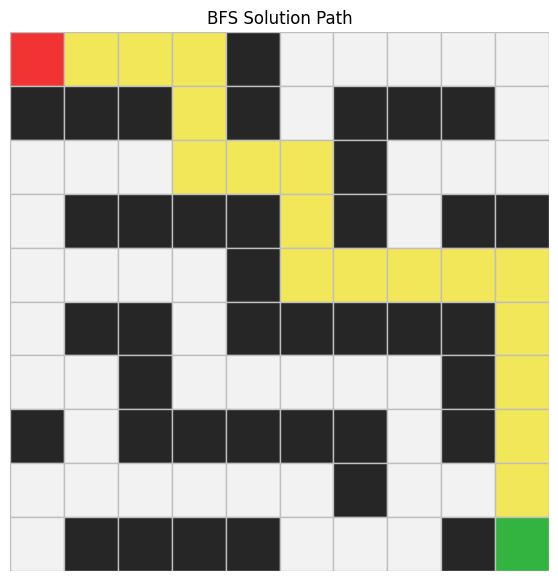

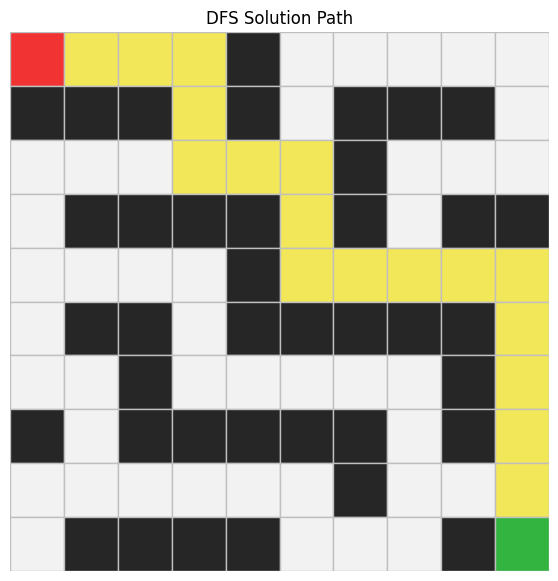

In [169]:
# Visualise solution paths.
# After your algorithms work, choose at least two algorithms and plot their paths.

bfs_result = results[0]
dfs_result = results[1]

plot_path(
    sample_grid,
    start,
    goal,
    path=bfs_result.path,
    title="BFS Solution Path",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=dfs_result.path,
    title="DFS Solution Path",
)

In [194]:
# TODO 10:
# Create your first custom map here.

custom_grid_1 = [[0,0,0,0,0,0,0,0,0,1],[1,0,1,0,1,0,1,1,1,1],[0,0,0,0,0,1,0,1,0,0],[1,1,0,0,0,0,0,1,1,1],[0,0,1,0,0,0,0,0,1,0],[0,0,0,0,1,1,1,0,0,0],[1,0,0,0,0,0,0,0,0,1],[1,0,0,0,0,0,1,0,0,0],
[0,0,0,0,0,0,0,0,0,0],[0,1,0,0,0,0,0,0,0,0]    # Replace this with your own grid.
]

custom_start_1 = (0,0)
custom_goal_1 = (8,7)

# Example after completing:
custom_problem_1 = GridProblem(custom_grid_1, custom_start_1, custom_goal_1)
custom_results_1 = [
     bfs.search(custom_problem_1),
     dfs.search(custom_problem_1),
     dls.search(custom_problem_1, limit=10),
     ids.search(custom_problem_1, max_depth=40),
 ]
show_results(custom_results_1)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,15.0,15.0,59,59,0
1,DFS,success,NaN,21.0,21.0,30,30,0
2,DLS,failure,10.0,NaN,NaN,1,1,0
3,IDS,cutoff,39.0,NaN,NaN,40,41,0


In [190]:
# TODO 11:
# Create your second custom map here.

custom_grid_2 = [
    [1,0,0,0,0,0,0,0,0,1],[1,0,0,0,1,0,0,0,1,1],[1,0,0,0,0,1,0,1,0,0],[1,1,0,0,0,0,0,1,0,1],[0,0,1,0,0,0,0,0,1,0],[0,0,0,0,1,0,1,0,0,0],[1,0,0,0,0,0,0,0,0,1],[1,0,0,0,0,0,1,0,0,0],
[0,0,0,0,0,1,0,0,0,0],[0,1,0,0,0,0,0,0,0,0],[0,0,0,0,0,0,0,0,0,1],[1,0,1,0,1,0,0,0,1,1],[0,0,0,0,0,1,0,1,0,0],[1,1,0,0,0,0,0,1,1,0],[0,0,1,0,0,0,0,0,0,0],[0,0,0,0,1,1,1,0,0,0],[1,0,0,0,0,0,0,0,0,1],[1,0,0,0,0,0,1,0,0,0],
[0,1,0,0,0,0,0,0,0,0],[1,1,0,0,0,0,0,0,0,1]
]

custom_start_2 = (1,3)
custom_goal_2 = (19,8)

# Example after completing:
custom_problem_2 = GridProblem(custom_grid_2, custom_start_2, custom_goal_2)
custom_results_2 = [
     #bfs.search(custom_problem_2),
     dfs.search(custom_problem_2),
     dls.search(custom_problem_2, limit=20),
     ids.search(custom_problem_2, max_depth=40),
 ]
show_results(custom_results_2)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,DFS,success,NaN,53.0,53.0,92,92,0
1,DLS,failure,20.0,NaN,NaN,1,1,0
2,IDS,cutoff,39.0,NaN,NaN,40,41,0
